# Aprendizaje anti-Hebbiano
## Dinámica del sistema

$$
\begin{align*}
&\dot{x} = W x &\\

&\dot{W} = \alpha (I - xx^T) &
\end{align*}
$$

## Algoritmo de evolución
He empleado una integración por Euler simple y funciona razonablemente bien para $dt\leq 0.1$
$$
\begin{align*}
x_{n+1, i} = x_{n, i} + W_{ij}x_jdt\\
W_{n+1, ij} = W_{n, ij} + \alpha(\delta_{i, j} - x_ix_j)dt
\end{align*}
$$

El siguiente diagrama de fase muestra como sistema unidimensional alcanza la estabilidad siempre 
independientemente del valor de α (siendo siempre positivo), 
alcanzando una orbita estacionaria en torno a x = ±1 y W = 0 de periodo T = 1/sqrt(2α).


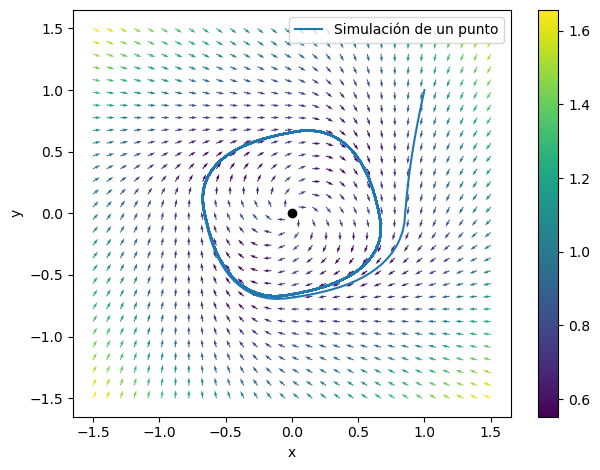

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.optimize as op


# Sistema de ecuaciones diferenciales 
def equations(vars):
   # Parámetros del sistema
   alpha = 1
   beta = 1
   gamma = 1
   delta = 1
   x, y = vars

   fx = -x + (2/np.pi)**(3/2) * (alpha * np.arctan2(x, np.abs(y)) + beta * np.arctan2(y, np.abs(x)))
   fy = -y + (2/np.pi)**(3/2) * (alpha * np.arctan2(y, np.abs(x)) - beta * np.arctan2(x, np.abs(y)))

   return fx, fy

# Buscamos los estados estacionarios
x_i = np.linspace(-10, 10, 15)
y_i = np.linspace(-10, 10, 15)

# FIX 1: Use meshgrid to create a full field of guesses, not just a diagonal line
X_guess, Y_guess = np.meshgrid(x_i, y_i)
initial_guesses = np.column_stack([X_guess.ravel(), Y_guess.ravel()])

stat = [[], []]

for guess in initial_guesses:
   result = op.root(fun=equations, x0=guess)
   if result.success:
      roots = result.x
      stat = np.column_stack((stat, roots))

# FIX 2: Add a safeguard to prevent crashes if no roots are found
if len(stat[0]) == 0:
    print("Aviso: No se encontraron estados estacionarios.")
    # Fallback values so the script can continue and plot an empty field
    x_min, x_max, y_min, y_max = 1, 1, 1, 1
    x_0, y_0 = [], [] 
else:
    x_0, y_0 = np.unique(np.round(stat, 5), axis=1)

    x_max = x_0.max()
    y_max = y_0.max()

    x_min = np.abs(x_0.min())
    y_min = np.abs(y_0.min())

n_cells = 30

# Rango de las variables
if x_min < 10E-5:
   x_min = 1
if x_max < 10E-5:
   x_max = 1
if y_min < 10E-5:
   y_min = 1
if y_max < 10E-5:
   y_max = 1

x = np.linspace(-1.5 * x_min, 1.5 * x_max, n_cells)
y = np.linspace(-1.5 * y_min, 1.5 * y_max, n_cells)




# Simulación de un punto
x_sim = [1]
y_sim = [1]
dt = 0.1

for i in range(3000):
   x_dot, y_dot = equations([x_sim[i], y_sim[i]])
   x_next = x_sim[i] + x_dot * dt
   y_next = y_sim[i] + y_dot * dt
   x_sim.append(x_next)
   y_sim.append(y_next)

plt.plot(x_sim, y_sim, label="Simulación de un punto")



# Creamos el grid con las posiciones
x_grid, y_grid = np.meshgrid(x, y)

fx = np.zeros_like(x_grid)
fy = np.zeros_like(x_grid)

for i in range(n_cells):
   for j in range(n_cells):
      fx[i, j], fy[i, j] = equations([x_grid[i, j], y_grid[i, j]])

magnitude = np.sqrt(fx ** 2 + fy ** 2)

# Graficamos el campo vectorial y los puntos fijos
plt.plot(x_0, y_0, 'k.',  markersize=12)
plt.quiver(x, y, fx / magnitude * 2, fy / magnitude * 2, magnitude, cmap='viridis', norm='linear')
# plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.colorbar()
plt.tight_layout()
print("El siguiente diagrama de fase muestra como sistema unidimensional alcanza la estabilidad siempre \n" \
"independientemente del valor de α (siendo siempre positivo), \n" \
"alcanzando una orbita estacionaria en torno a x = ±1 y W = 0 de periodo T = 1/sqrt(2α).")